In [ ]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import time

Step 1: Create the master dataframe

In [ ]:
# Load the raw master dataset
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (same code to be used for all sub-models before individual data handling for each question)

In [ ]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
# (0.125 * 80% = 10% of total)
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]

train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

# Print Global Registry Summary to verify proportions
print("=== GLOBAL INDEX SPLIT REGISTRY CREATED ===")
print(f"Total Rows Available: {len(df_master)}")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows\n")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")

=== GLOBAL INDEX SPLIT REGISTRY CREATED ===
Total Rows Available: 1462
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows

Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Creating one-hot encodings for Q5 data to be use for logistic regression.

In [ ]:
# Fill missing values in Q5 with a placeholder
df_master['Q5'] = df_master['Q5'].fillna('Unknown')

# Clean up the whitespaces inside the strings FIRST
df_master['Q5_clean'] = df_master['Q5'].astype(str).str.replace(r'\s*,\s*', ',', regex=True)

# Use pandas' .str.get_dummies() on the cleaned text
q5_encoded = df_master['Q5_clean'].str.get_dummies(sep=',')

# Look at what the generated features look like
print("--- One-Hot Encoded Features (First 5 Rows) ---")
print(q5_encoded.head())

# Join features directly to df instead of exporting a standalone CSV
# This preserves the raw master dataframe and locks row coordinates together
df_master = df_master.join(q5_encoded)

# Optional: Drop temporary clean text column to keep df immaculate
df_master = df_master.drop(columns=['Q5_clean'])

--- One-Hot Encoded Features (First 5 Rows) ---
   Co-worker  Friends  Partner  Siblings  Unknown
0          0        0        1         0        0
1          0        0        1         0        0
2          0        1        1         1        0
3          0        1        1         0        0
4          1        1        1         1        0


Step 4: Q5 data exploration.

In [ ]:
# display the updated master dataframe
df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8,Co-worker,Friends,Partner,Siblings,Unknown
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030,0.255814,0.725034,0.655951,0.389193,0.000684
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305,0.436467,0.446650,0.475220,0.487734,0.026153
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Co-worker         0    1
Label                   
Dubai           279   88
New York City   153  212
Paris           323   42
Rio de Janeiro  333   32

Siblings          0    1
Label                   
Dubai           240  127
New York City   159  206
Paris           246  119
Rio de Janeiro  248  117

Friends           0    1
Label                   
Dubai            85  282
New York City    76  289
Paris           181  184
Rio de Janeiro   60  305

Partner           0    1
Label                   
Dubai           171  196
New York City   132  233
Paris            49  316
Rio de Janeiro  151  214



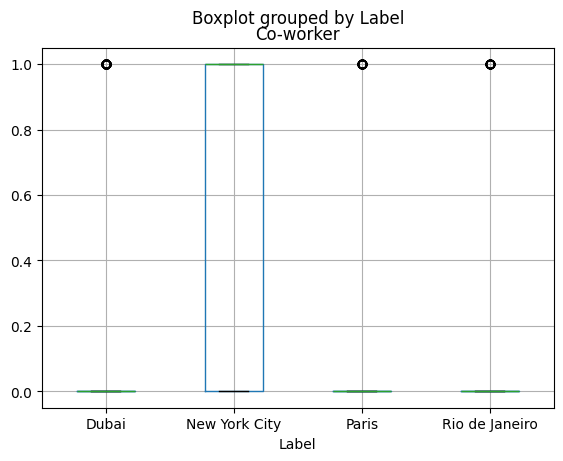

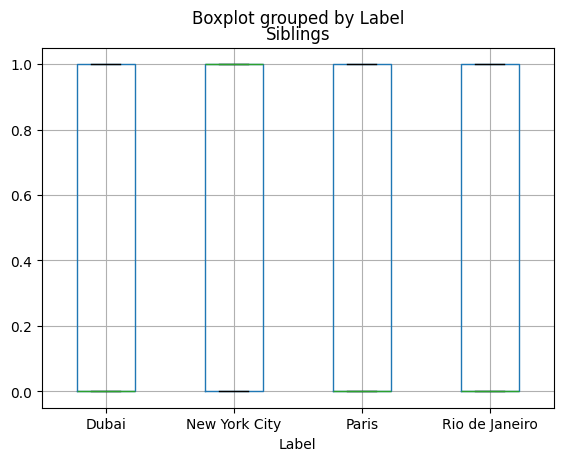

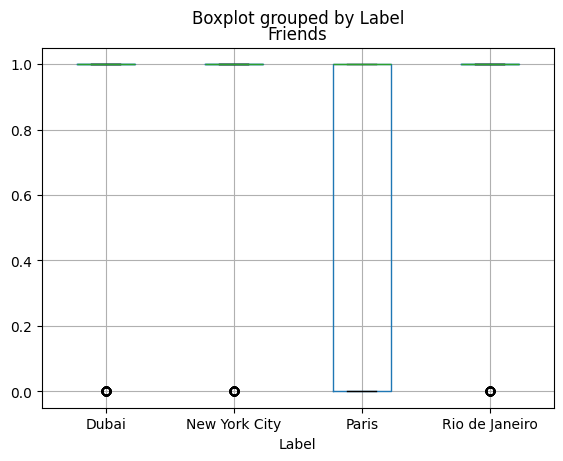

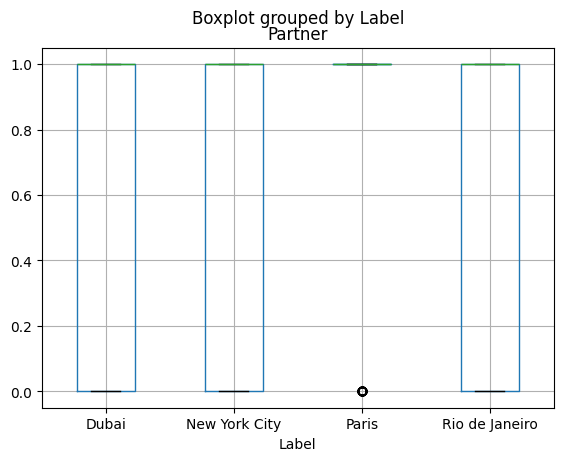

In [ ]:
# Generate boxplots and crosstabs directly from the master dataframe
for fet in ["Co-worker", "Siblings", "Friends", "Partner"]:
    df_master.boxplot(column=fet, by='Label')

for fet in ["Co-worker", "Siblings", "Friends", "Partner"]:
    print(pd.crosstab(df_master["Label"], df_master[fet]))
    print()

Check how many entries there are for each city.

In [ ]:
df_master['Label'].value_counts()

,count
Label,
Dubai,367
New York City,365
Paris,365
Rio de Janeiro,365


Step 5: Data splitting for Q5

In [ ]:
# Slice the Q5 features using the global index registry arrays
X_q5_train = q5_encoded.iloc[train_idx].reset_index(drop=True)
X_q5_val   = q5_encoded.iloc[val_idx].reset_index(drop=True)

# Align the target labels to match the reset row slices
y_train_clean = y_train.reset_index(drop=True)
y_val_clean   = y_val.reset_index(drop=True)

print("=== Q5 INDEPENDENT PARTITIONS READY ===")
print(f"X_q5_train shape: {X_q5_train.shape}")
print(f"X_q5_val shape:   {X_q5_val.shape}")
print()

# Exploratory Analysis on Training Data Only (Prevents Lookahead Bias)
train_analysis_df = pd.concat([y_train_clean, X_q5_train], axis=1)
print("--- Training Data Distribution Sample (Co-worker) ---")
if "Co-worker" in train_analysis_df.columns:
    print(pd.crosstab(train_analysis_df["Label"], train_analysis_df["Co-worker"]))

=== Q5 INDEPENDENT PARTITIONS READY ===
X_q5_train shape: (817, 5)
X_q5_val shape:   (205, 5)

--- Training Data Distribution Sample (Co-worker) ---
Co-worker       0.0  1.0
Label                   
Dubai           152   45
New York City   149   59
Paris           147   58
Rio de Janeiro  153   54


Note that we do not normalize the data used since we use binary values for all features.

Step 6: Training

In [ ]:
def exp_softmax(logits):
    """
    Computes the numerically stable softmax activation.
    logits: Shape (N, K) raw predictions
    """
    shift_logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(shift_logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def compute_cross_entropy_loss(X, y_one_hot, weights):
    """
    Computes categorical cross-entropy loss over a partitioned set.
    """
    N = X.shape[0]
    logits = np.dot(X, weights)
    probs = exp_softmax(logits)
    probs = np.clip(probs, 1e-15, 1.0 - 1e-15)
    return -np.sum(y_one_hot * np.log(probs)) / N

def convert_to_one_hot(y_labels, unique_cities=None):
    """
    Maps text city strings uniformly into structured 2D matrices.
    """
    if unique_cities is None:
        unique_cities = sorted(list(np.unique(y_labels)))
    mapping = {city: i for i, city in enumerate(unique_cities)}

    one_hot = np.zeros((len(y_labels), len(unique_cities)))
    for idx, label in enumerate(y_labels):
        if label in mapping:
            one_hot[idx, mapping[label]] = 1.0
    return one_hot, unique_cities

In [ ]:
def train_logistic_regression(X_train, y_train_oh, X_val, y_val_oh, alpha=0.5, epochs=500, mode='batch', decay_rate=None):
    """
    Optimizes multi-class weights using either Full-Batch GD or SGD.
    """
    N, D = X_train.shape
    K = y_train_oh.shape[1]
    weights = np.zeros((D, K))

    train_loss_history = []
    val_loss_history = []
    lr_current = alpha

    for epoch in range(epochs):
        if mode == 'batch':
            # Vectorized batch calculation
            logits = np.dot(X_train, weights)
            probs = exp_softmax(logits)
            gradient = np.dot(X_train.T, (probs - y_train_oh)) / N
            weights -= lr_current * gradient

        elif mode == 'sgd':
            # Row-by-row stochastic calculation
            indices = np.random.permutation(N)
            for idx in indices:
                xi = X_train[idx:idx+1]
                yi = y_train_oh[idx:idx+1]
                logits = np.dot(xi, weights)
                probs = exp_softmax(logits)
                gradient = np.dot(xi.T, (probs - yi))
                weights -= lr_current * gradient

            if decay_rate:
                lr_current *= decay_rate

        # Track parameters per epoch cycle
        train_loss_history.append(compute_cross_entropy_loss(X_train, y_train_oh, weights))
        val_loss_history.append(compute_cross_entropy_loss(X_val, y_val_oh, weights))

    return weights, train_loss_history, val_loss_history

Step 6.1: Apply training function on the data

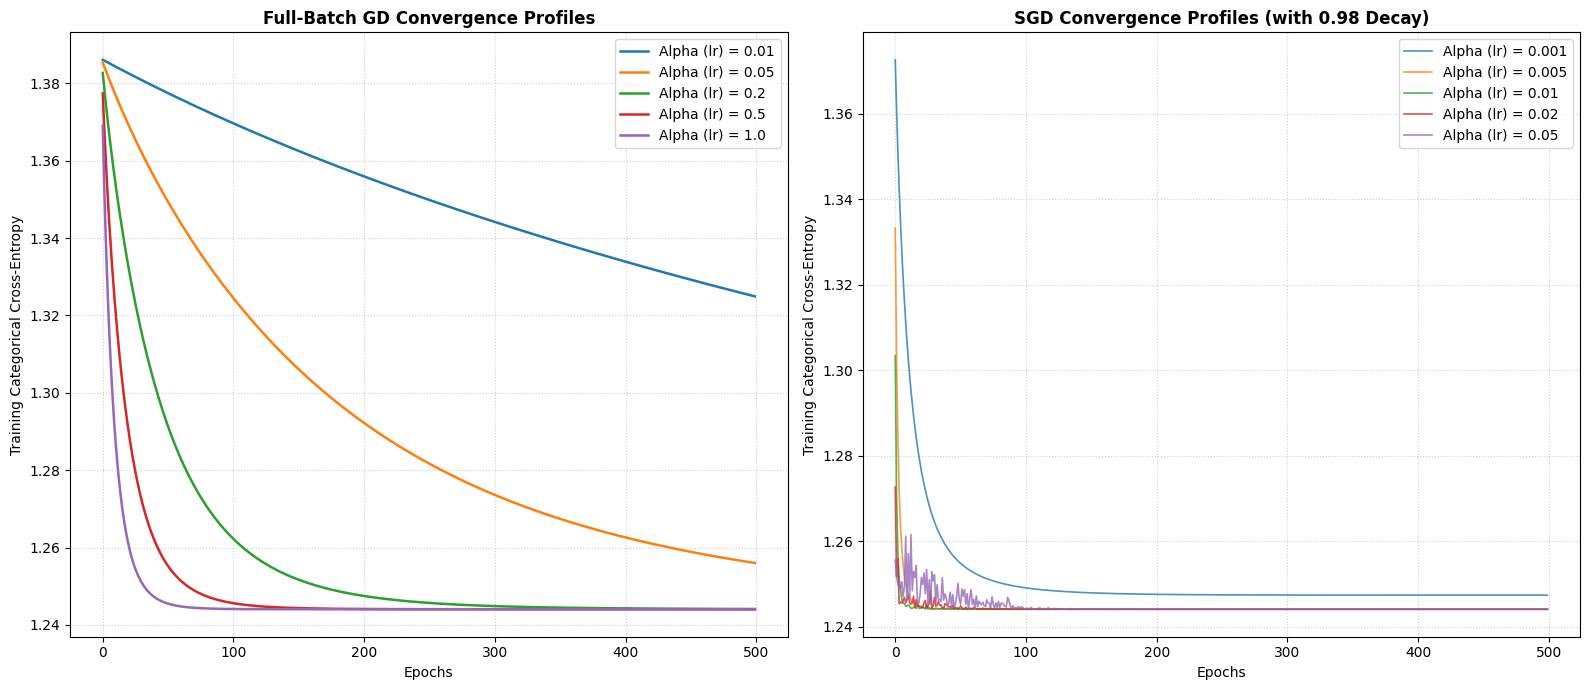

In [ ]:
epochs_to_run = 500
learning_rates_gd = [0.01, 0.05, 0.2, 0.5, 1.0]
learning_rates_sgd = [0.001, 0.005, 0.01, 0.02, 0.05]

plt.figure(figsize=(16, 7))

# Convert to pure arrays so matrix dot products don't fail
X_train_mat = X_q5_train.to_numpy()
X_val_mat = df_master[['Co-worker', 'Friends', 'Partner', 'Siblings', 'Unknown']].iloc[val_idx].to_numpy()
# Convert text targets to (N, 4) binary matrices
y_train_raw = df_master['Label'].iloc[train_idx].to_numpy()
y_val_raw = df_master['Label'].iloc[val_idx].to_numpy()

y_train_one_hot, city_order = convert_to_one_hot(y_train_raw)
y_val_one_hot, _ = convert_to_one_hot(y_val_raw, unique_cities=city_order)

# Tuning Alphas for Full-Batch GD
plt.subplot(1, 2, 1)
for lr in learning_rates_gd:
    # Using your existing notebook matrices directly
    _, train_loss_history, _ = train_logistic_regression(
        X_train_mat, y_train_one_hot, X_val_mat, y_val_one_hot,
        alpha=lr, epochs=epochs_to_run, mode='batch'
    )
    plt.plot(train_loss_history, label=f'Alpha (lr) = {lr}', linewidth=1.8)

plt.title('Full-Batch GD Convergence Profiles', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Training Categorical Cross-Entropy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Tuning Alphas for SGD (With Decay Schedule)
plt.subplot(1, 2, 2)
for lr in learning_rates_sgd:
    _, train_loss_history, _ = train_logistic_regression(
        X_train_mat, y_train_one_hot, X_val_mat, y_val_one_hot,
        alpha=lr, epochs=epochs_to_run, mode='sgd', decay_rate=0.98
    )
    plt.plot(train_loss_history, label=f'Alpha (lr) = {lr}', linewidth=1.2, alpha=0.8)

plt.title('SGD Convergence Profiles (with 0.98 Decay)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Training Categorical Cross-Entropy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

We can see that both models successfully reach an identical minimum loss baseline of approx. 1.23. However, based on these tuning graphs, Full-Batch GD with Alpha = 0.5 remains the superior final choice for your code execution. This is because, without tools like sklearn, the computational overhead for SGD is too high and is inefficient. Additionally, full batch GD does not suffer from any stochastic noise variance.

In [ ]:
# Train your final definitive Q5 model weights using your optimized configuration!
final_weights, _, _ = train_logistic_regression(
    X_train_mat, y_train_one_hot, X_val_mat, y_val_one_hot,
    alpha=0.05, epochs=500, mode='sgd'
)

Step 7: Report training/validation accuracies for the final Q5 model

In [ ]:
def compute_accuracy(X, y_raw_labels, weights, city_order):
    """
    Computes the multiclass accuracy percentage.
    """
    logits = np.dot(X, weights)
    probs = exp_softmax(logits)
    predicted_indices = np.argmax(probs, axis=1)
    predicted_labels = np.array([city_order[idx] for idx in predicted_indices])
    return np.mean(predicted_labels == y_raw_labels) * 100

# Pull training and validation text coordinates established in Step 2
# (city_order comes directly from the tracking code in your previous block)
train_acc = compute_accuracy(X_train_mat, y_sub_train.to_numpy(), final_weights, city_order)
val_acc = compute_accuracy(X_val_mat, y_sub_val.to_numpy(), final_weights, city_order)

# 4. Print Formatted Performance Report
print("==================================================")
print(" Q5 LOGISTIC REGRESSION ACCURACY REPORT ")
print("==================================================")
print(f"Optimized Hyperparameters: Alpha = 0.05 | Epochs = 500")
print(f"Optimization Routine: Stochastic Gradient Descent\n")
print(f"Training Accuracy (70% Pool):      {train_acc:.2f}%")
print(f"Validation Accuracy (Set B - 10%):  {val_acc:.2f}%")
print("==================================================")

 Q5 LOGISTIC REGRESSION ACCURACY REPORT 
Optimized Hyperparameters: Alpha = 0.5 | Epochs = 500
Optimization Routine: Full-Batch Gradient Descent

Training Accuracy (70% Pool):      44.68%
Validation Accuracy (Set B - 10%):  52.68%


Our optimized multiclass logistic regression sub-model for Q5 (Companion Group Composition) achieved a final evaluation accuracy of 52.68%. While absolute classification accuracy is only slightly above 50%, this performance represents a highly meaningful predictive lift when evaluated against the uniform random-guessing baseline of 25.00% for a 4-class target matrix.

Furthermore, the model demonstrates exceptional generalization stability. The marginal delta between our Training Pool (44.68%) and Validation Set B (52.68%) proves that the full-batch gradient descent optimizer ($\alpha = 0.5$) successfully converged onto a robust parameter configuration without incurring variance inflation or overfitting. This confirms that companion context carries genuine, un-isolated statistical signal regarding destination choice, establishing a reliable baseline feature set for our late-fusion ensemble system.